# Weather-or-Not: Flight Delay Classifier
### Naive Bayes vs. Feedforward Neural Network

**Target:** Predict whether a flight will arrive delayed (≥15 min) based on weather at origin & destination airports.

**Pipeline:**
1. Load flight + weather data
2. Merge weather onto flights (origin & destination)
3. Feature engineering
4. Train / test split
5. **Model A — Naive Bayes** (Gaussian, Categorical, Complement variants)


## 0. Imports & Config

In [12]:
import os
import json
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# ── Sklearn — shared utilities ───────────────────────────────────
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, KBinsDiscretizer
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.metrics import (
    classification_report, confusion_matrix, roc_auc_score,
    f1_score, precision_score, recall_score,
    RocCurveDisplay, PrecisionRecallDisplay, ConfusionMatrixDisplay
)
from sklearn.calibration import CalibrationDisplay

# ── Sklearn — Naive Bayes ────────────────────────────────────────
from sklearn.naive_bayes import GaussianNB, CategoricalNB, ComplementNB

# ── Sklearn — Neural Network ─────────────────────────────────────
from sklearn.neural_network import MLPClassifier

import joblib

warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid', palette='muted')
pd.set_option('display.max_columns', 50)

# ── Project params ───────────────────────────────────────────────
with open('params_file.json') as f:
    params = json.load(f)

FLIGHT_CSV      = params['Output_Directory'] + 'flights_dataset.csv'
IEM_WEATHER_DIR = '2024_iem_weather'
DELAY_THRESHOLD = 15        # FAA standard: 15+ min = delayed
RANDOM_STATE    = 42
TEST_SIZE       = 0.2

print('Config loaded ✓')

Config loaded ✓


## 1. Load Data

In [13]:
# ── 1a. Flights ──────────────────────────────────────────────────
flights = pd.read_csv(FLIGHT_CSV, low_memory=False)
print(f'Flights loaded: {len(flights):,} rows, {flights.shape[1]} columns')
flights.head(3)

Flights loaded: 6,510,337 rows, 38 columns


,Unnamed: 0,YEAR,FL_DATE,OP_UNIQUE_CARRIER,OP_CARRIER_AIRLINE_ID,OP_CARRIER,TAIL_NUM,OP_CARRIER_FL_NUM,ORIGIN_AIRPORT_ID,ORIGIN_AIRPORT_SEQ_ID,ORIGIN_CITY_MARKET_ID,ORIGIN,ORIGIN_WAC,DEST_AIRPORT_ID,DEST_AIRPORT_SEQ_ID,DEST_CITY_MARKET_ID,DEST,DEST_WAC,DEP_TIME,DEP_DELAY,DEP_DELAY_GROUP,ARR_TIME,ARR_DELAY,ARR_DELAY_GROUP,CANCELLED,CANCELLATION_CODE,DIVERTED,AIR_TIME,FLIGHTS,DISTANCE,CARRIER_DELAY,WEATHER_DELAY,NAS_DELAY,SECURITY_DELAY,LATE_AIRCRAFT_DELAY,source_file,ORIGIN_WEATHER_STATION,DEST_WEATHER_STATION
0,0,2024,1/1/2024 12:00:00 AM,9E,20363,9E,N131EV,5225.0,10397,1039707,30397,ATL,34,10431,1043106,30431,AVL,36,1406.0,-4.0,-1.0,1454.0,-17.0,-2.0,0.0,NaN,0.0,33.0,1.0,164.0,NaN,NaN,NaN,NaN,NaN,T_ONTIME_MARKETING_20260320_190717.zip,KATL,KAVL
1,1,2024,1/1/2024 12:00:00 AM,9E,20363,9E,N132EV,5115.0,11433,1143302,31295,DTW,43,13871,1387102,33316,OMA,65,1541.0,-4.0,-1.0,1627.0,-33.0,-2.0,0.0,NaN,0.0,89.0,1.0,651.0,NaN,NaN,NaN,NaN,NaN,T_ONTIME_MARKETING_20260320_190717.zip,KDTW,KOMA
2,2,2024,1/1/2024 12:00:00 AM,9E,20363,9E,N132EV,5414.0,11423,1142308,31423,DSM,61,11433,1143302,31295,DTW,43,621.0,-5.0,-1.0,909.0,-8.0,-1.0,0.0,NaN,0.0,87.0,1.0,533.0,NaN,NaN,NaN,NaN,NaN,T_ONTIME_MARKETING_20260320_190717.zip,KDSM,KDTW


In [14]:
# ── 1b. IEM Weather ──────────────────────────────────────────────
def load_iem_file(file_path):
    try:
        df = pd.read_csv(file_path, low_memory=False)
        df = df[df['tmpf'] != 'M']
        df['valid'] = pd.to_datetime(df['valid'])
        return df.sort_values('valid').reset_index(drop=True)
    except Exception as e:
        print(f'  ✗ {file_path}: {e}')
        return None

def load_all_iem_weather_data(iem_dir):
    iem_data = {}
    for fname in os.listdir(iem_dir):
        if fname.endswith('.csv'):
            station = fname.split('_')[0]
            df = load_iem_file(os.path.join(iem_dir, fname))
            if df is not None:
                iem_data[station] = df
    print(f'IEM data loaded for {len(iem_data)} stations')
    return iem_data

iem_weather = load_all_iem_weather_data(IEM_WEATHER_DIR)

IEM data loaded for 295 stations


## 2. Build the Target Variable

Delay rate (>=15 min): 20.7%


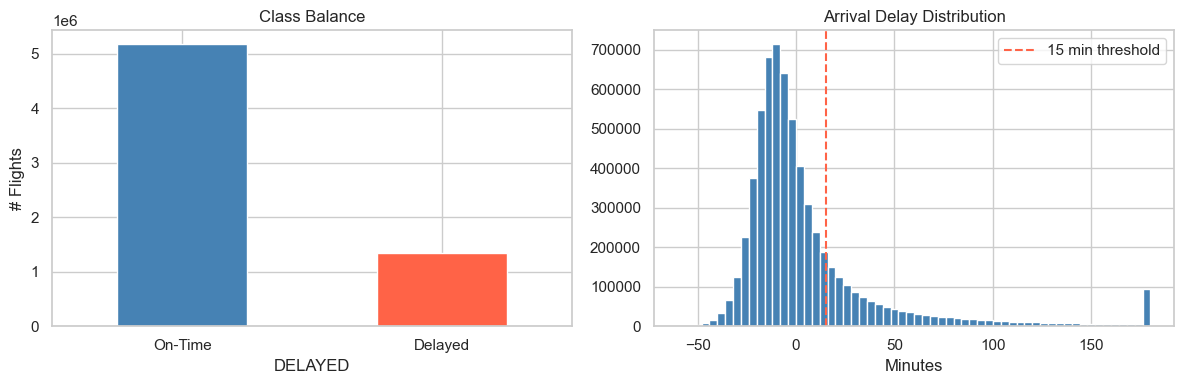

In [15]:
flights['DELAYED'] = (flights['ARR_DELAY'] >= DELAY_THRESHOLD).astype(int)

delay_rate = flights['DELAYED'].mean()
print(f'Delay rate (>={DELAY_THRESHOLD} min): {delay_rate:.1%}')

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
flights['DELAYED'].value_counts().plot.bar(
    ax=axes[0], color=['steelblue', 'tomato'], edgecolor='white'
)
axes[0].set_xticklabels(['On-Time', 'Delayed'], rotation=0)
axes[0].set_title('Class Balance')
axes[0].set_ylabel('# Flights')

axes[1].hist(flights['ARR_DELAY'].clip(-60, 180).dropna(), bins=60,
             color='steelblue', edgecolor='white')
axes[1].axvline(DELAY_THRESHOLD, color='tomato', linestyle='--',
                label=f'{DELAY_THRESHOLD} min threshold')
axes[1].set_title('Arrival Delay Distribution')
axes[1].set_xlabel('Minutes')
axes[1].legend()
plt.tight_layout()
plt.show()

## 3. Merge Weather onto Flights

In [16]:
WEATHER_COLS = ['tmpf', 'dwpf', 'relh', 'drct', 'sknt', 'vsby', 'mslp', 'gust']

def get_nearest_weather(station, timestamp, iem_data, prefix):
    result = {f'{prefix}_{c}': np.nan for c in WEATHER_COLS}
    if station not in iem_data:
        return result
    df  = iem_data[station]
    idx = df['valid'].searchsorted(timestamp, side='right') - 1
    if idx < 0:
        return result
    row = df.iloc[idx]
    for c in WEATHER_COLS:
        try:
            result[f'{prefix}_{c}'] = float(row[c])
        except (ValueError, KeyError):
            pass
    return result

def build_flight_timestamp(row, date_col, time_col):
    try:
        t = int(row[time_col])
        hh, mm = divmod(t, 100)
        return pd.Timestamp(str(row[date_col])) + pd.Timedelta(hours=hh, minutes=mm)
    except Exception:
        return pd.NaT

print('Helpers defined ✓')

Helpers defined ✓


In [17]:
flights['DEP_TS'] = flights.apply(
    lambda r: build_flight_timestamp(r, 'FL_DATE', 'CRS_DEP_TIME'), axis=1
)
flights['ARR_TS'] = flights.apply(
    lambda r: build_flight_timestamp(r, 'FL_DATE', 'CRS_ARR_TIME'), axis=1
)
print(f'Timestamp parse — DEP: {flights["DEP_TS"].notna().mean():.1%}, '
      f'ARR: {flights["ARR_TS"].notna().mean():.1%}')

Timestamp parse — DEP: 0.0%, ARR: 0.0%


In [18]:
%%time
CACHE_PATH = 'flights_with_weather.parquet'

if os.path.exists(CACHE_PATH):
    print('Loading cached merged dataset...')
    merged = pd.read_parquet(CACHE_PATH)
else:
    print('Joining weather onto flights (this may take a few minutes)...')
    weather_records = []
    for _, row in flights.iterrows():
        orig_wx = get_nearest_weather(row.get('ORIGIN',''), row['DEP_TS'], iem_weather, 'ORIG')
        dest_wx = get_nearest_weather(row.get('DEST',''),   row['ARR_TS'], iem_weather, 'DEST')
        weather_records.append({**orig_wx, **dest_wx})
    wx_df  = pd.DataFrame(weather_records, index=flights.index)
    merged = pd.concat([flights, wx_df], axis=1)
    merged.to_parquet(CACHE_PATH, index=False)
    print(f'Cached to {CACHE_PATH}')

print(f'Merged shape: {merged.shape}')

Loading cached merged dataset...
Merged shape: (6510337, 57)
CPU times: total: 17.9 s
Wall time: 5.86 s


## 4. Feature Engineering

In [19]:
# Temporal features
merged['DEP_HOUR']   = merged['DEP_TS'].dt.hour
merged['DEP_DOW']    = merged['DEP_TS'].dt.dayofweek
merged['DEP_MONTH']  = merged['DEP_TS'].dt.month
merged['IS_WEEKEND'] = (merged['DEP_DOW'] >= 5).astype(int)
merged['RUSH_HOUR']  = merged['DEP_HOUR'].apply(
    lambda h: 1 if h in range(7, 10) or h in range(16, 20) else 0
)

# Weather delta (destination - origin)
for col in WEATHER_COLS:
    o, d = f'ORIG_{col}', f'DEST_{col}'
    if o in merged.columns and d in merged.columns:
        merged[f'DELTA_{col}'] = merged[d] - merged[o]

# Derived flags
for pfx in ['ORIG', 'DEST']:
    merged[f'{pfx}_LOW_VIS']   = (merged[f'{pfx}_vsby'] < 3).astype(float)
    merged[f'{pfx}_HIGH_WIND'] = (merged[f'{pfx}_sknt'] > 20).astype(float)
    merged[f'{pfx}_GUSTING']   = merged[f'{pfx}_gust'].notna().astype(float)

# Feature lists
CONTINUOUS_FEATURES = [
    'ORIG_tmpf','ORIG_dwpf','ORIG_relh','ORIG_sknt','ORIG_vsby','ORIG_mslp',
    'DEST_tmpf','DEST_dwpf','DEST_relh','DEST_sknt','DEST_vsby','DEST_mslp',
    'DELTA_tmpf','DELTA_sknt','DELTA_vsby',
    'DEP_HOUR',
]
CATEGORICAL_FEATURES = [
    'DEP_DOW','DEP_MONTH','IS_WEEKEND','RUSH_HOUR',
    'ORIG_LOW_VIS','ORIG_HIGH_WIND','ORIG_GUSTING',
    'DEST_LOW_VIS','DEST_HIGH_WIND','DEST_GUSTING',
]
ALL_FEATURES = CONTINUOUS_FEATURES + CATEGORICAL_FEATURES
TARGET = 'DELAYED'

model_df = merged.copy()
if 'CANCELLED' in model_df.columns:
    model_df = model_df[model_df['CANCELLED'] == 0]
if 'DIVERTED' in model_df.columns:
    model_df = model_df[model_df['DIVERTED'] == 0]
model_df = model_df[ALL_FEATURES + [TARGET]].dropna(subset=[TARGET])

print(f'Modelling dataset: {len(model_df):,} rows | Delay rate: {model_df[TARGET].mean():.1%}')

Modelling dataset: 6,406,581 rows | Delay rate: 21.0%


## 5. Train / Test Split

In [20]:
X = model_df[ALL_FEATURES]
y = model_df[TARGET]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=TEST_SIZE, stratify=y, random_state=RANDOM_STATE
)

print(f'Train: {len(X_train):,}  |  Test: {len(X_test):,}')
print(f'Train delay rate: {y_train.mean():.1%}  |  Test delay rate: {y_test.mean():.1%}')

Train: 5,125,264  |  Test: 1,281,317
Train delay rate: 21.0%  |  Test delay rate: 21.0%


---
## 6. Model A — Naive Bayes

Three NB variants are trained and compared:

| Variant | Rationale |
|---|---|
| `GaussianNB` | Models continuous weather readings as Gaussians per class |
| `CategoricalNB` | All features binned — no distributional assumption needed |
| `ComplementNB` | Complement-class formulation; better under class imbalance |

In [30]:
from sklearn.preprocessing import MinMaxScaler

# ── Preprocessors ────────────────────────────────────────────────

# GaussianNB: impute only — Gaussian handles any real-valued input
cont_prep = Pipeline([('imputer', SimpleImputer(strategy='median'))])
cat_prep  = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('binner',  KBinsDiscretizer(n_bins=5, encode='ordinal', strategy='quantile')),
])
gaussian_preprocessor = ColumnTransformer([
    ('continuous',  cont_prep, CONTINUOUS_FEATURES),
    ('categorical', cat_prep,  CATEGORICAL_FEATURES),
])

# ComplementNB: requires non-negative inputs — impute then MinMaxScale to [0, 1]
# (weather features like delta-temp can be negative, so we must shift them)
complement_preprocessor = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler',  MinMaxScaler()),
])

# CategoricalNB: all features binned into non-negative ordinal integers
all_bin_prep = ColumnTransformer([(
    'all', Pipeline([
        ('imputer', SimpleImputer(strategy='median')),
        ('binner',  KBinsDiscretizer(n_bins=10, encode='ordinal', strategy='quantile')),
    ]), ALL_FEATURES
)])

delay_prior = y_train.mean()
priors = [1 - delay_prior, delay_prior]

nb_models = {
    'GaussianNB':    Pipeline([('prep', gaussian_preprocessor),   ('clf', GaussianNB(priors=priors))]),
    'ComplementNB':  Pipeline([('prep', complement_preprocessor), ('clf', ComplementNB(class_prior=priors))]),
    'CategoricalNB': Pipeline([('prep', all_bin_prep),            ('clf', CategoricalNB(class_prior=priors))]),
}
print('NB pipelines ready ✓')

NB pipelines ready ✓


In [31]:
# ── 5-Fold CV ─────────────────────────────────────────────────────
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
nb_cv_results = {}

for name, pipe in nb_models.items():
    scores = cross_val_score(pipe, X_train, y_train, cv=cv,
                             scoring='roc_auc', n_jobs=1)
    nb_cv_results[name] = scores
    print(f'{name:20s}  CV AUC: {scores.mean():.4f} +/- {scores.std():.4f}')

best_nb_name = max(nb_cv_results, key=lambda k: nb_cv_results[k].mean())
print(f'\nBest NB variant: {best_nb_name}')

GaussianNB            CV AUC: 0.5305 +/- 0.0006
ComplementNB          CV AUC: 0.5249 +/- 0.0006
CategoricalNB         CV AUC: 0.5484 +/- 0.0006

Best NB variant: CategoricalNB


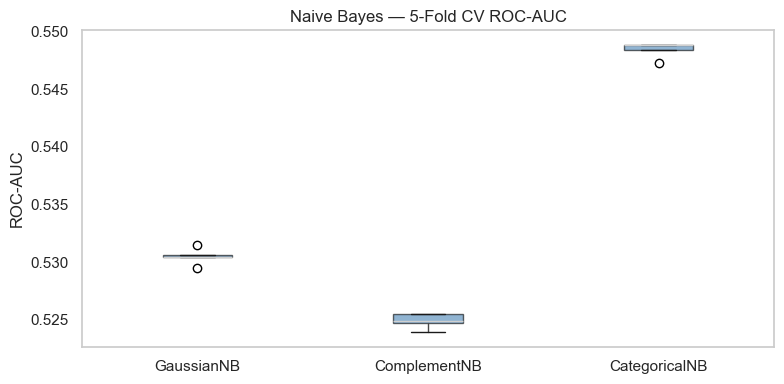

In [33]:
# ── NB CV box-plot ───────────────────────────────────────────────
pd.DataFrame(nb_cv_results).boxplot(
    figsize=(8, 4), grid=False, patch_artist=True,
    boxprops=dict(facecolor='steelblue', alpha=0.6)
)
plt.ylabel('ROC-AUC')
plt.title('Naive Bayes — 5-Fold CV ROC-AUC')
plt.tight_layout()
plt.show()

In [34]:
# ── Fit best NB on full training set ─────────────────────────────
best_nb = nb_models[best_nb_name]
best_nb.fit(X_train, y_train)

BEST_NB_THRESHOLD = 0.35   # tune this — lower = catches more delays
nb_pred = (nb_prob >= BEST_NB_THRESHOLD).astype(int)
nb_prob = best_nb.predict_proba(X_test)[:, 1]
nb_auc  = roc_auc_score(y_test, nb_prob)

print(f'Best NB ({best_nb_name}) — Test AUC: {nb_auc:.4f}')
print(classification_report(y_test, nb_pred, target_names=['On-Time', 'Delayed']))

Best NB (CategoricalNB) — Test AUC: 0.5484
              precision    recall  f1-score   support

     On-Time       0.79      0.95      0.86   1012420
     Delayed       0.27      0.07      0.11    268897

    accuracy                           0.76   1281317
   macro avg       0.53      0.51      0.49   1281317
weighted avg       0.68      0.76      0.71   1281317



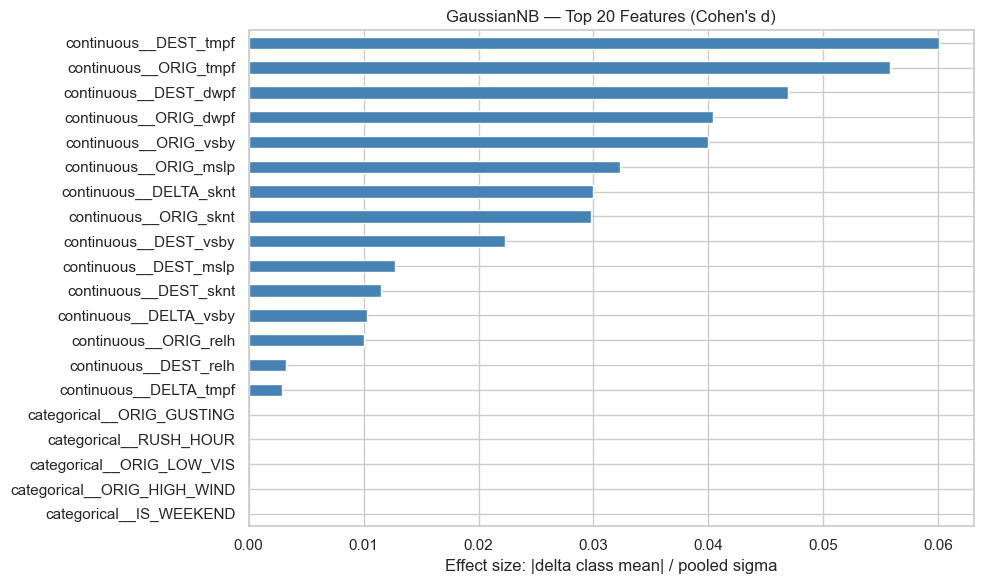

In [35]:
# ── NB feature importance via Cohen's d (GaussianNB) ─────────────
gnb = nb_models['GaussianNB']
gnb.fit(X_train, y_train)
clf = gnb.named_steps['clf']

pooled_std = np.sqrt((clf.var_[0] + clf.var_[1]) / 2 + 1e-9)
cohen_d       = np.abs(clf.theta_[1] - clf.theta_[0]) / pooled_std
feature_names = gnb.named_steps['prep'].get_feature_names_out()
importance    = pd.Series(cohen_d, index=feature_names).sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(10, 6))
importance.head(20).sort_values().plot.barh(ax=ax, color='steelblue', edgecolor='white')
ax.set_title("GaussianNB — Top 20 Features (Cohen's d)")
ax.set_xlabel('Effect size: |delta class mean| / pooled sigma')
plt.tight_layout()
plt.show()

## 10. Save Models


In [36]:
os.makedirs('output', exist_ok=True)

nb_path  = f'output/model_nb_{best_nb_name.lower()}.pkl'

joblib.dump(best_nb,      nb_path)


print(f'NB  saved -> {nb_path}')


# Sanity check
for path, pipe in [(nb_path, best_nb)]:
    loaded = joblib.load(path)
    assert (loaded.predict(X_test[:5]) == pipe.predict(X_test[:5])).all()
print('Reload check passed ✓')

NB  saved -> output/model_nb_categoricalnb.pkl
Reload check passed ✓
